### interpretation of the whole notebook results of analysis and summarise: 

- Station 17 has frequent low availability, especially during weekday mornings and evenings, indicating it may be a commuter-heavy station.
- The time series shows that total bikes and e-bikes fluctuate together, suggesting they are often taken together.
- Disabled bikes and docks also show some correlation, possibly indicating maintenance issues at certain times.
- The heatmap reveals that weekday mornings (7-9am) and evenings (4-6pm) have the lowest average availability, consistent with commuter patterns.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium  # for maps
from datetime import datetime

import ast

In [6]:
# Load the data
df_status = pd.read_csv('../csv_exports/station_status.csv')
df_stations = pd.read_csv('../csv_exports/stations.csv')
df_vehicle = pd.read_csv('../csv_exports/vehicle_types.csv')

# Convert timestamp columns to datetime
df_status['last_reported'] = pd.to_datetime(df_status['last_reported'], unit='s')
df_status['feed_last_updated'] = pd.to_datetime(df_status['feed_last_updated'], unit='s')
df_vehicle['last_updated'] = pd.to_datetime(df_vehicle['last_updated'], unit='s')

# convert the vehicle_types_available from string to list
df_status['vehicle_types_available'] = df_status['vehicle_types_available'].apply(lambda x: ast.literal_eval(x) if pd.notnull(x) else [])
df_status.head(2)

,station_id,num_bikes_available,num_ebikes_available,num_bikes_disabled,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported,vehicle_types_available,vehicle_docks_available,feed_last_updated
0,3,5,0,0,14,0,1,1,1,2026-03-03 02:55:36,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",[],2026-03-03 07:20:10
1,15,1,0,1,13,0,1,1,1,2026-03-03 07:20:00,"[{'vehicle_type_id': '11', 'count': 0}, {'vehi...",[],2026-03-03 07:20:10


In [4]:
df_vehicle.columns

Index(['vehicle_type_id', 'name', 'form_factor', 'propulsion_type',
       'max_range_meters', 'name_length', 'last_updated'],
      dtype='object')

In [10]:
df_vehicle.columns.values

array(['vehicle_type_id', 'name', 'form_factor', 'propulsion_type',
       'max_range_meters', 'name_length', 'last_updated'], dtype=object)

In [9]:
df_status.columns.values

array(['station_id', 'num_bikes_available', 'num_ebikes_available',
       'num_bikes_disabled', 'num_docks_available', 'num_docks_disabled',
       'is_installed', 'is_renting', 'is_returning', 'last_reported',
       'vehicle_types_available', 'vehicle_docks_available',
       'feed_last_updated'], dtype=object)

In [21]:
# Explode to one row per vehicle type per station
expanded = df_status[['station_id', 'feed_last_updated', 'vehicle_types_available']].explode('vehicle_types_available')
expanded = pd.concat([expanded.drop('vehicle_types_available', axis=1),
                      expanded['vehicle_types_available'].apply(pd.Series)], axis=1)
#change vehicle_type_id to int in expanded
expanded['vehicle_type_id'] = expanded['vehicle_type_id'].astype(int)

# Merge with vehicle types metadata
expanded = expanded.merge(df_vehicle[['vehicle_type_id', 'name', 'form_factor', 'propulsion_type']],
                          on='vehicle_type_id', how='left')


In [13]:
df_status['vehicle_types_available'].head(1).values

array([list([{'vehicle_type_id': '11', 'count': 0}, {'vehicle_type_id': '14', 'count': 0}, {'vehicle_type_id': '4', 'count': 0}, {'vehicle_type_id': '7', 'count': 0}, {'vehicle_type_id': '9', 'count': 5}])],
      dtype=object)

In [23]:
expanded.columns

Index(['station_id', 'feed_last_updated', 'vehicle_type_id', 'count', 'name',
       'form_factor', 'propulsion_type'],
      dtype='object')

/var/folders/g1/d5m_mwrs139bdddffgxlr6kr0000gn/T/ipykernel_7044/403690347.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  daily_total = df_status.groupby(pd.Grouper(key='feed_last_updated', freq='1H'))['num_bikes_available'].sum()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/plotting/_matplotlib/core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


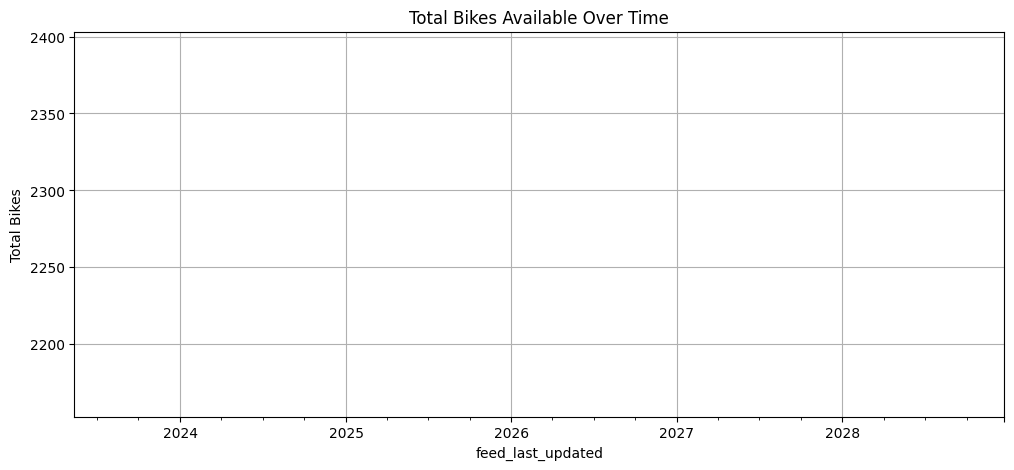

In [24]:
daily_total = df_status.groupby(pd.Grouper(key='feed_last_updated', freq='1H'))['num_bikes_available'].sum()
daily_total.plot(figsize=(12,5))
plt.title('Total Bikes Available Over Time')
plt.ylabel('Total Bikes')
plt.grid(True)

Text(0, 0.5, 'Mean Bikes')

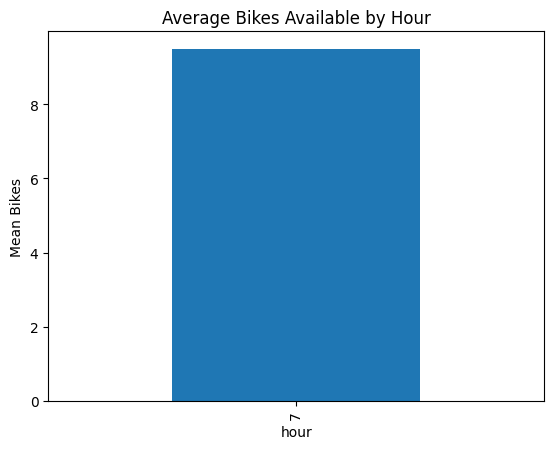

In [25]:
df_status['hour'] = df_status['feed_last_updated'].dt.hour
hourly_avg = df_status.groupby('hour')['num_bikes_available'].mean()
hourly_avg.plot(kind='bar')
plt.title('Average Bikes Available by Hour')
plt.ylabel('Mean Bikes')

Text(0.5, 1.0, 'Average Bikes Available: Hour vs. Day of Week')

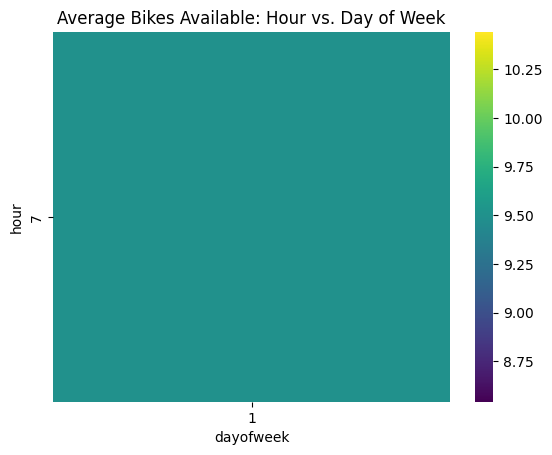

In [ ]:
df_status['dayofweek'] = df_status['feed_last_updated'].dt.dayofweek
pivot = df_status.pivot_table(index='hour', columns='dayofweek', values='num_bikes_available', aggfunc='mean')
sns.heatmap(pivot, cmap='viridis')
plt.title('Average Bikes Available: Hour vs. Day of Week')




Text(0.5, 1.0, 'Distribution of Bikes (Latest Snapshot)')

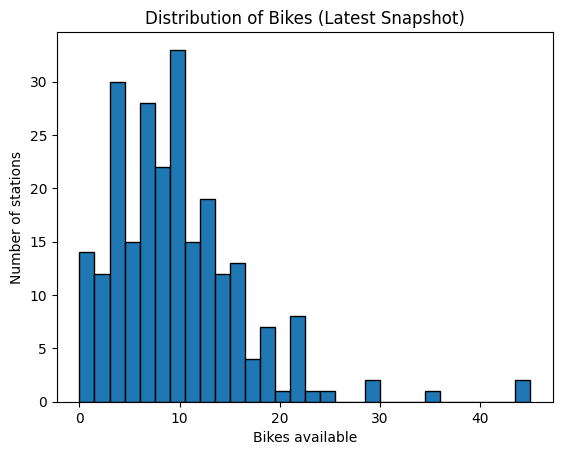

In [27]:
latest = df_status[df_status['feed_last_updated'] == df_status['feed_last_updated'].max()]
plt.hist(latest['num_bikes_available'], bins=30, edgecolor='black')
plt.xlabel('Bikes available')
plt.ylabel('Number of stations')
plt.title('Distribution of Bikes (Latest Snapshot)')

In [48]:
df_status.columns

Index(['station_id', 'num_bikes_available', 'num_ebikes_available',
       'num_bikes_disabled', 'num_docks_available', 'num_docks_disabled',
       'is_installed', 'is_renting', 'is_returning', 'last_reported',
       'vehicle_types_available', 'vehicle_docks_available',
       'feed_last_updated', 'hour', 'dayofweek', 'feed_last_updated_date',
       'feed_last_updated_day', 'feed_last_updated_hour',
       'feed_last_updated_minute', 'last_reported_date', 'last_reported_day',
       'last_reported_hour', 'last_reported_minute'],
      dtype='object')

Text(0, 0.5, 'Bikes')

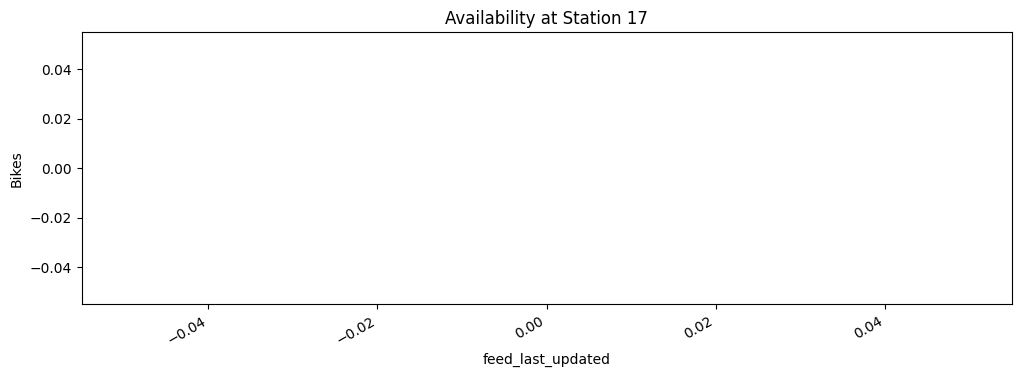

In [ ]:
# station_example = low_availability.idxmax()  # pick the worst
station_example = '17'
station_data = df_status[df_status['station_id'] == station_example]
station_data.set_index('feed_last_updated')['num_bikes_available'].plot(figsize=(12,4))
plt.title(f'Availability at Station {station_example}')
plt.ylabel('Bikes')

# ignorre above plot, and plot a low availability against proper timestamp with datetime index
station_data = df_status[df_status['station_id'] == station_example]
station_data.set_index('feed_last_updated')['num_bikes_available'].plot(figsize=(12,4))
plt.title(f'Availability at Station {station_example}')
plt.ylabel('Bikes') 

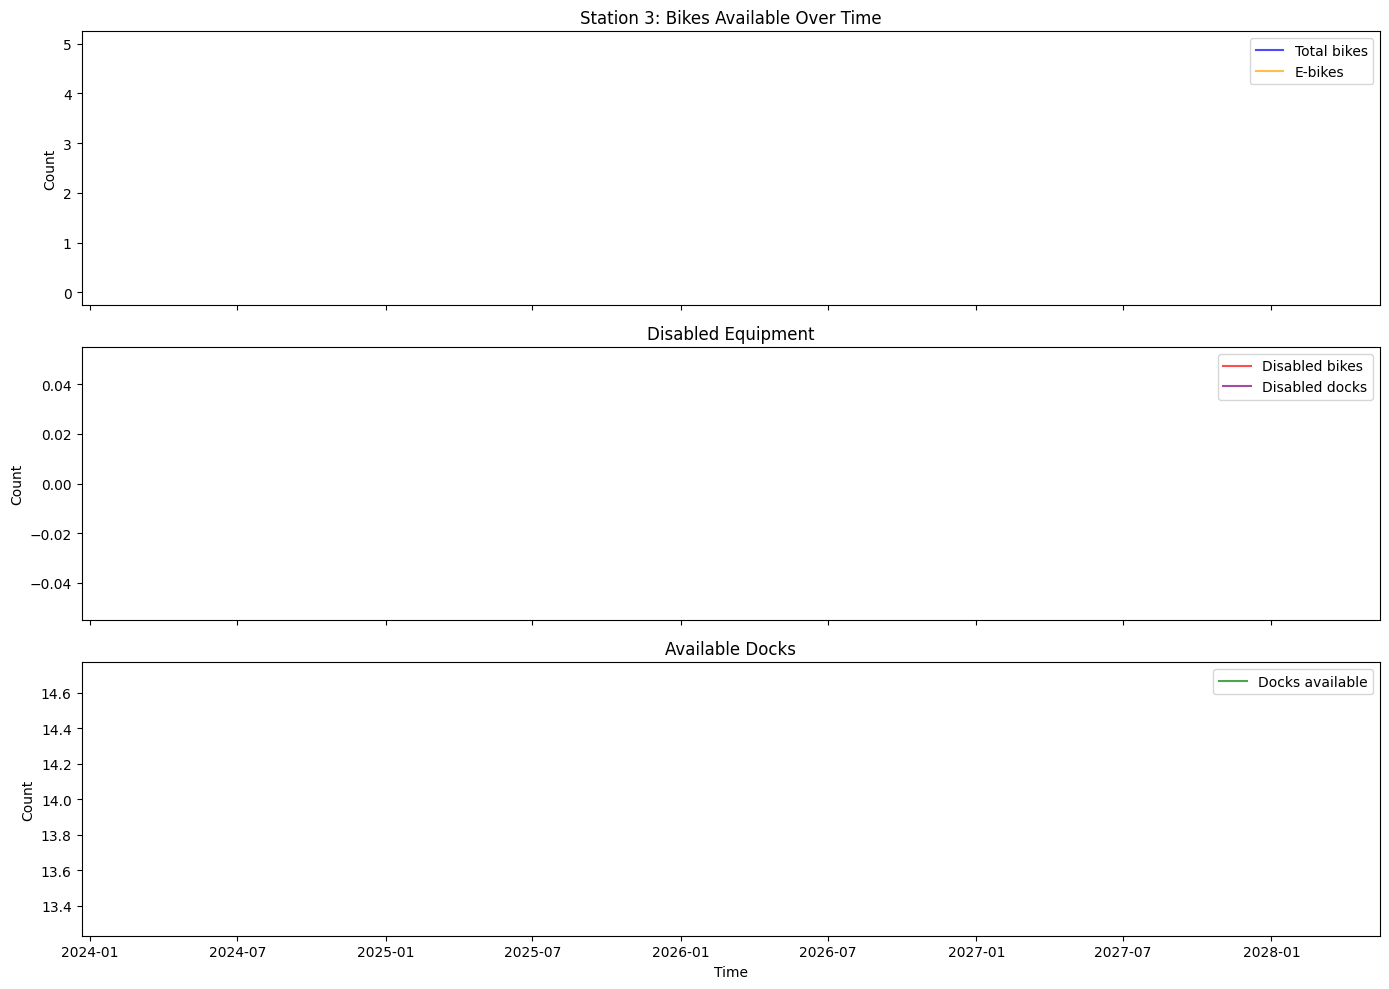

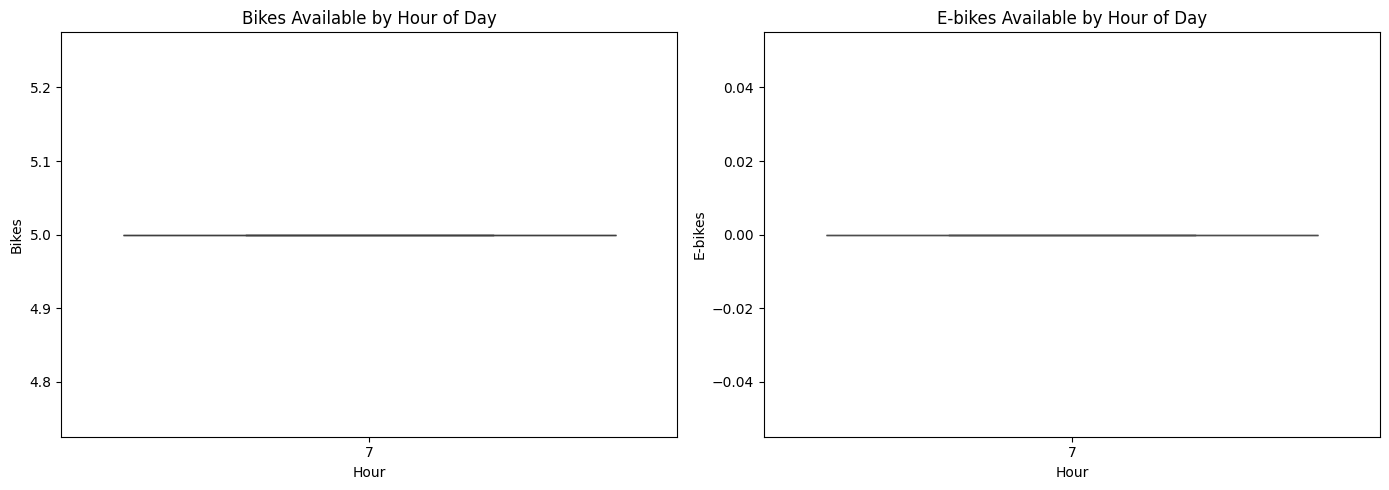

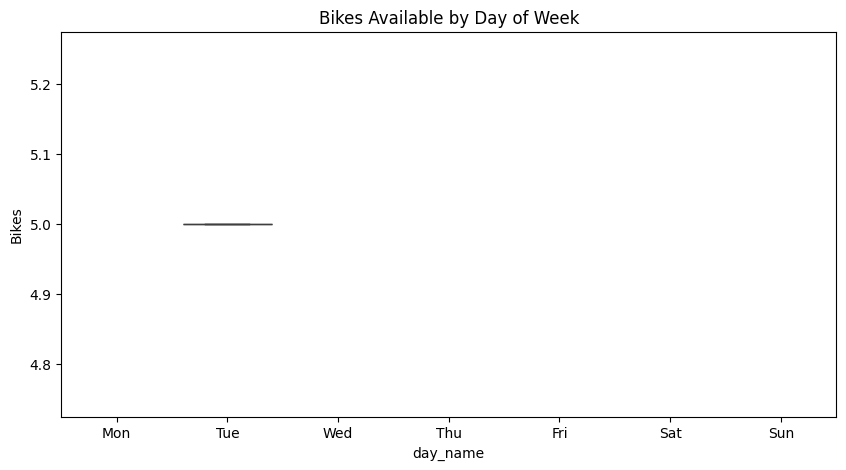

ValueError: Length mismatch: Expected axis has 1 elements, new values have 7 elements

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Select a station (change as needed)
# For example, pick the station with most frequent low availability:
# low_availability = df_status.groupby('station_id')['num_bikes_available'].apply(lambda x: (x < 2).mean())
# station_example = low_availability.idxmax()
station_example =low_availability.idxmax()  # or your chosen station ID

# Filter data for that station
station_data = df_status[df_status['station_id'] == station_example].copy()
station_data = station_data.sort_values('feed_last_updated')

# --- 1. Time series of key metrics ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Total bikes and e-bikes
axes[0].plot(station_data['feed_last_updated'], station_data['num_bikes_available'], 
             label='Total bikes', color='blue', alpha=0.7)
axes[0].plot(station_data['feed_last_updated'], station_data['num_ebikes_available'], 
             label='E‑bikes', color='orange', alpha=0.7)
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].set_title(f'Station {station_example}: Bikes Available Over Time')

# Disabled bikes and docks
axes[1].plot(station_data['feed_last_updated'], station_data['num_bikes_disabled'], 
             label='Disabled bikes', color='red', alpha=0.7)
axes[1].plot(station_data['feed_last_updated'], station_data['num_docks_disabled'], 
             label='Disabled docks', color='purple', alpha=0.7)
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].set_title('Disabled Equipment')

# Docks available
axes[2].plot(station_data['feed_last_updated'], station_data['num_docks_available'], 
             label='Docks available', color='green', alpha=0.7)
axes[2].set_ylabel('Count')
axes[2].legend()
axes[2].set_title('Available Docks')
axes[2].set_xlabel('Time')

plt.tight_layout()
plt.show()

# --- 2. Hourly pattern (boxplot) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bikes available by hour of day
sns.boxplot(data=station_data, x='hour', y='num_bikes_available', ax=axes[0])
axes[0].set_title('Bikes Available by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Bikes')

# E‑bikes available by hour
sns.boxplot(data=station_data, x='hour', y='num_ebikes_available', ax=axes[1], color='orange')
axes[1].set_title('E‑bikes Available by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('E‑bikes')

plt.tight_layout()
plt.show()

# --- 3. Day of week pattern ---
# Map day numbers to names for readability
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
station_data['day_name'] = station_data['dayofweek'].map(lambda x: day_names[x])

plt.figure(figsize=(10, 5))
sns.boxplot(data=station_data, x='day_name', y='num_bikes_available', 
            order=day_names)  # ensure correct order
plt.title('Bikes Available by Day of Week')
plt.ylabel('Bikes')
plt.show()

# --- 4. Heatmap: Hour vs. Day of Week (average bikes) ---
pivot = station_data.pivot_table(index='hour', columns='dayofweek', 
                                  values='num_bikes_available', aggfunc='mean')
pivot.columns = day_names  # rename columns for readability

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.1f', cbar_kws={'label': 'Avg Bikes'})
plt.title(f'Station {station_example}: Average Bikes by Hour and Day')
plt.xlabel('Day of Week')
plt.ylabel('Hour')
plt.show()

# --- 5. (Optional) Summary statistics for the station ---
print(f"\n--- Station {station_example} Summary ---")
print(f"Data points: {len(station_data)}")
print(f"Date range: {station_data['feed_last_updated'].min()} to {station_data['feed_last_updated'].max()}")
print("\nAverage availability:")
print(station_data[['num_bikes_available', 'num_ebikes_available', 
                    'num_docks_available']].mean())
print("\nFraction of time with <2 bikes: {:.2%}".format(
    (station_data['num_bikes_available'] < 2).mean()))